In [ ]:
#1. ENIRONMENT SETUP
# ====================================================

#Installation
!pip install easyocr
!pip install pytesseract
!pip install pdf2image
!sudo apt-get install tesseract-ocr
!apt-get install -y poppler-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 35.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s

In [ ]:
#Libraries
import pytesseract
from pdf2image import convert_from_path
import torch
import pandas as pd
import re
import spacy
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# =====================================================
# 1. NLP CLASSIFIER
# =====================================================
class NLPClassifier:
    """
    NLP classifier that predicts the document category
    from OCR-extracted text using keyword matching.
    """
    def __init__(self):
        #specify the categories to classify the doc into
        self.categories = [
            ("Grant of conditional planning permission", ["grant of conditional"]),
            ("Notice of approval of details", ["notice of approval of details", "approval of details"]),
            ("Application for planning permission notice of approval", ["application for planning permission", "notice of approval"]),
            ("Planning charges", ["planning charges", "planning fee", "charge"])
        ]

    def predict(self, text):
        """
        Predict category by checking specific phrases first.
        """
        text_lower = text.lower()

        for label, kws in self.categories:
            for kw in kws:
                if kw in text_lower:
                    return label

        return "Other Document"


# =====================================================
# 2. EXTRACTION ENGINE A
# =====================================================
class ExtractionEngineA:
    def clean_ocr(self, text):
        fixes = {
            "mrse": "mrs",
            "mr s": "mrs",
            "m r": "mr",
            "applicant ;": "applicant:",
            "applicants ;": "applicants:"
        }
        text = text.lower()
        for k, v in fixes.items():
            text = text.replace(k, v)
        return text

    def extract_application_numbers(self, text):
        pattern = r'\b(?:[A-Z]{1,2}/)?\d{2,4}/\d{2,4}(?:/\d{2,4})?\b'
        results = re.findall(pattern, text, re.IGNORECASE)
        valid_results = [r for r in results if len(r) > 5]
        return sorted(list(set(valid_results)))

    def extract_applicants(self, text):
        text_clean = self.clean_ocr(text)
        if "as named on the reverse" in text_clean:
            return ["As named on the reverse"]

        name_pattern = r'\b(mr|mrs|ms|miss|dr)\.?\s+(?:[a-z]{1,2}\.?\s*){0,3}[a-z]+'
        lines = [l.strip() for l in text_clean.split('\n') if l.strip()]

        for i, line in enumerate(lines):
            if "applicant" in line:
                for offset in range(0,3):
                    if i + offset < len(lines):
                        candidate = lines[i+offset]
                        if "i or ry" in candidate.lower() or "ae" in candidate.lower():
                            return ["None"]
                        match = re.search(name_pattern, candidate, re.IGNORECASE)
                        if match:
                            return [match.group().title()]
                        if offset > 0:
                            blacklist = [
                                "road","street","avenue","lane",
                                "town hall","london","borough","agent"
                            ]
                            if 3 < len(candidate) < 35 and not any(
                                word in candidate.lower() for word in blacklist
                            ):
                                if re.search(r'[a-zA-Z]', candidate):
                                    return [candidate.title()]

        couple = re.search(
            r'mr\.?\s*&\s*mrs\.?\s*(?:[a-z]\.?\s*){0,3}[a-z]+',
            text_clean,
            re.IGNORECASE
        )
        if couple:
            return [couple.group().title()]

        single = re.search(name_pattern, text_clean, re.IGNORECASE)
        if single:
            return [single.group().title()]

        return ["N/A"]


# =====================================================
# 3. EXTRACTION ENGINE B
# =====================================================
class ExtractionEngineB:
    def __init__(self):
        try:
            self.nlp = spacy.load("en_core_web_sm")
        except:
            os.system("python -m spacy download en_core_web_sm")
            self.nlp = spacy.load("en_core_web_sm")

    def extract_applicants(self, text):
        lines = [l.strip() for l in text.split("\n") if l.strip()]
        applicants = []
        for i, line in enumerate(lines):
            lower_line = line.lower()
            if "applicant" in lower_line:
                if ":" in line:
                    name = line.split(":")[-1].strip()
                elif i + 1 < len(lines):
                    name = lines[i+1].strip()
                else:
                    continue
                name = re.sub(r'[^A-Za-z\s\.\-]', '', name).strip()
                blacklist = ["council","road","street","london","borough","agent"]
                if 4 < len(name) < 80 and not any(b in name.lower() for b in blacklist):
                    applicants.append(name)
        return list(set(applicants))



# =====================================================
# 4. PIPELINE A
# =====================================================
def run_pipeline_A(pdf_path):
    pages = convert_from_path(pdf_path, dpi=300)

    # NLPClassifier
    nlp_classifier = NLPClassifier()
    extractor = ExtractionEngineA()

    results = []

    for i, page in enumerate(pages):
        # Run OCR on page
        text = pytesseract.image_to_string(page)

        # Predict category using NLP classifier
        doc_type = nlp_classifier.predict(text)

        # Extract applicant names and application numbers
        raw_applicants = extractor.extract_applicants(text)
        raw_app_numbers = extractor.extract_application_numbers(text)

        clean_applicant = ", ".join(raw_applicants) if raw_applicants else "N/A"
        clean_app_number = ", ".join(raw_app_numbers) if raw_app_numbers else "N/A"

        results.append({
            "Page": i+1,
            "Category": doc_type,
            "Application_Number": clean_app_number,
            "Applicants": clean_applicant
        })

    df = pd.DataFrame(results)
    return df

  # =====================================================
# 5. PIPELINE B
# =====================================================
def run_pipeline_B(pdf_path):
    pages = convert_from_path(pdf_path)
    extractor = ExtractionEngineB()
    results = []
    for page_number, img in enumerate(pages, start=1):
        text = pytesseract.image_to_string(
            img,
            config="--oem 3 --psm 6"
        )
        names = extractor.extract_applicants(text)
        for name in names:
            results.append({
                "Page": page_number,
                "Applicants_B": name
            })
    df = pd.DataFrame(results)
    df = df.drop_duplicates("Page")
    return df



# =====================================================
# 6. MERGE + FILL MISSING APPLICANTS
# =====================================================
def merge_results(df_A, df_B):
    df = df_A.merge(df_B, on="Page", how="left")
    df["Applicants"] = df["Applicants"].replace(
        ["N/A","None","",None],
        pd.NA
    )
    df["Applicants"] = df["Applicants"].fillna(df["Applicants_B"])
    df = df.drop(columns=["Applicants_B"])
    df = df.set_index("Page")
    return df


# =====================================================
# 7. RUN COMPLETE PIPELINE
# =====================================================
if __name__ == "__main__":
    FILE_PATH = "/content/drive/MyDrive/anonymised 1.pdf"

    df_A = run_pipeline_A(FILE_PATH)
    df_B = run_pipeline_B(FILE_PATH)
    final_df = merge_results(df_A, df_B)


    print("\nFinal Combined Results\n")
    print(final_df)

    final_df.to_csv("final_extracted_metadata.csv")


Final Combined Results

                                               Category  \
Page                                                      
1                                      Planning charges   
2     Application for planning permission notice of ...   
3              Grant of conditional planning permission   
4                         Notice of approval of details   

                     Application_Number               Applicants  
Page                                                              
1     02/80/1609, 02/81/1237, 1954/1992        Mr. & Mrs.J.M Doe  
2                 17/07/2000, P/00/0759                Mr M Dale  
3                                   N/A  As named on the reverse  
4      13/07/1996, P/96/0900, P/98/0964          Mrs AM Stephens  


In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================

#Inspect the Data
print(final_df.info())

# 1. Convert "N/A", "None", and actual NaNs to a unified format
missing_mask = final_df.isin(['N/A', 'None', None, np.nan])

# 2. Convert that mask into a PyTorch Tensor (1 for missing, 0 for present)
missing_tensor = torch.tensor(missing_mask.values.astype(int))

# 3. Perform the summation using PyTorch
# dim=0 sums across rows (giving you the count per column)
missing_counts = torch.sum(missing_tensor, dim=0)

print("\nMissing Value Counts per Column:")
for i, col in enumerate(final_df.columns):
    print(f"{col}: {missing_counts[i].item()}")


<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 1 to 4
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Category            4 non-null      object
 1   Application_Number  4 non-null      object
 2   Applicants          4 non-null      object
dtypes: object(3)
memory usage: 128.0+ bytes
None

Missing Value Counts per Column:
Category: 0
Application_Number: 1
Applicants: 0


In [ ]:
# DATA WRANGLING
# =====================================================

#Create a copy of the dataset
data_c = final_df.copy()

#create a column for Date
def extract_date(row):
    # Ignore Planning charges rows
    if row["Category"].lower() == "planning charges":
        return None

    # Find date pattern inside Application Number column
    match = re.search(r'\b\d{2}/\d{2}/\d{4}\b', str(row["Application_Number"]))

    return match.group(0) if match else None

data_c["Date_of_Application"] = data_c.apply(extract_date, axis=1)

#standardising the application number column
def clean_application_numbers(row):

    # Keep Planning charges unchanged
    if row["Category"].lower() == "planning charges":
        return row["Application_Number"]

    # Remove any dd/mm/yyyy pattern
    cleaned = re.sub(r'\b\d{2}/\d{2}/\d{4}\b', '', str(row["Application_Number"]))

    # Remove leftover commas or spaces
    cleaned = re.sub(r'\s*,\s*,', ',', cleaned)
    cleaned = cleaned.strip(' ,')

    return cleaned if cleaned else "N/A"


data_c["Application_Number"] = data_c.apply(clean_application_numbers, axis=1)

## Count application numbers per record
data_c['App_Num_Count'] = data_c['Application_Number'].apply(lambda x: len(x.split(',')) if x != 'None' else 0)

data_c

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Category,Application_Number,Applicants,Date_of_Application,App_Num_Count
Page,,,,,
1,Planning charges,"02/80/1609, 02/81/1237, 1954/1992",Mr. & Mrs.J.M Doe,None,3
2,Application for planning permission notice of ...,P/00/0759,Mr M Dale,17/07/2000,1
3,Grant of conditional planning permission,N/A,As named on the reverse,None,1
4,Notice of approval of details,"P/96/0900, P/98/0964",Mrs AM Stephens,13/07/1996,2


/tmp/ipykernel_1852/2796000853.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mask = data_c.applymap(lambda x: str(x).strip() not in invalid_placeholders and pd.notnull(x))


Completeness percentages by column: [100.0, 75.0, 100.0, 50.0, 100.0]


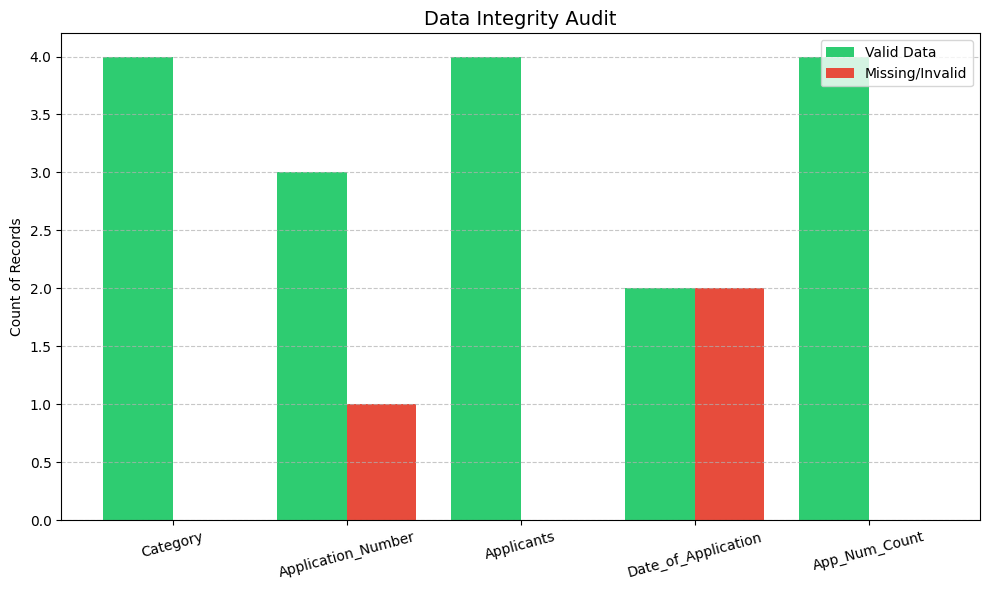

In [ ]:
# VISUALIZING DATA QUALITY IN ONE VIEW
# =====================================================

# 1. Define "Missingness" Logic (N/A and None are treated as Missing)
def check_completeness(data_c):
    invalid_placeholders = ['None', 'N/A', '', 'n/a']
    # Create a mask where True = Valid Data, False = Missing/Placeholder
    mask = data_c.applymap(lambda x: str(x).strip() not in invalid_placeholders and pd.notnull(x))
    return mask

mask_data_c = check_completeness(data_c)

# 2. Convert completeness mask to Tensor for analysis
completeness_tensor = torch.tensor(mask_data_c.values.astype(int), dtype=torch.float32)
col_completeness = torch.mean(completeness_tensor, dim=0) * 100

print(f"Completeness percentages by column: {col_completeness.tolist()}")

# 3. Visualization: Single plot for all columns
cols = list(data_c.columns)
valid_counts = mask_data_c.sum().values
missing_counts = (len(data_c) - mask_data_c.sum()).values

x = np.arange(len(cols))
width = 0.4

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, valid_counts, width, label='Valid Data', color='#2ecc71')
plt.bar(x + width/2, missing_counts, width, label='Missing/Invalid', color='#e74c3c')

plt.title('Data Integrity Audit', fontsize=14)
plt.xticks(x, cols, rotation=15)
plt.ylabel('Count of Records')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save for documentation
plt.savefig('completeness_audit.png')

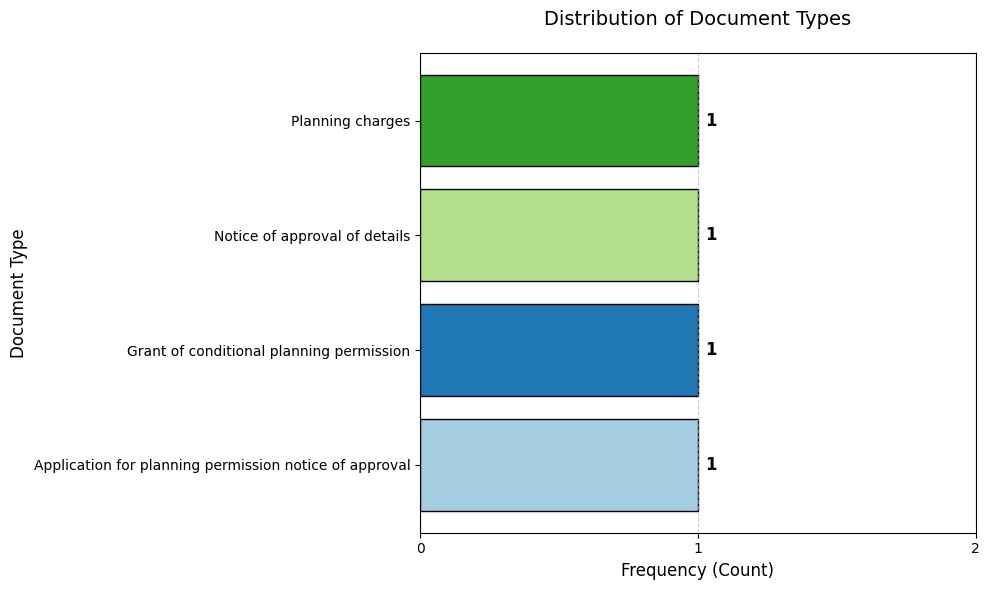

In [ ]:
# DOCUMENT TYPE DISTRIBUTION
#==========================================

# 1. Get counts and  convert 'Category' to categorical codes
type_series = data_c['Category'].astype('category')
type_indices = torch.tensor(type_series.cat.codes.values)

#Get unique indices and their frequencies
unique_indices, counts = torch.unique(type_indices, return_counts=True)
labels = type_series.cat.categories[unique_indices.tolist()]

# 2. Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Create horizontal bar chart
colors = plt.cm.Paired(range(len(labels)))
bars = ax.barh(labels, counts.numpy(), color=colors, edgecolor='black')

# Add the count numbers to the end of each bar
ax.bar_label(bars, padding=5, fontsize=12, fontweight='bold')

# 3. Formatting
ax.set_title('Distribution of Document Types', fontsize=14, pad=20)
ax.set_xlabel('Frequency (Count)', fontsize=12)
ax.set_ylabel('Document Type', fontsize=12)

# Ensure x-axis only shows integers and has some "breathing room"
ax.set_xticks(range(0, int(counts.max()) + 2))

ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()